In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

employees = pd.read_csv('../data/raw/employees.csv')
tasks = pd.read_csv('../data/raw/tasks.csv')

# Always start with these three
print(employees.shape)        # rows x columns
print(employees.dtypes)       # data types
print(employees.isnull().sum()) # missing values per column

print(tasks.shape)
print(tasks.describe())       # statistical summary

(200, 8)
employee_id          object
name                 object
department           object
role                 object
join_date            object
years_experience    float64
manager_id           object
location             object
dtype: object
employee_id         0
name                0
department          0
role                0
join_date           0
years_experience    0
manager_id          0
location            0
dtype: int64
(2000, 14)
       hours_estimated  hours_actual  efficiency_score  satisfaction_rating
count       2000.00000   1719.000000       1719.000000          1719.000000
mean          20.90450     26.333508         80.016056             2.988365
std           11.17174     17.489390         10.259223             1.401348
min            2.00000      1.000000         47.300000             1.000000
25%           11.00000     11.900000         73.400000             2.000000
50%           21.00000     23.000000         80.100000             3.000000
75%           30.0000

In [2]:
# Check how many tasks are incomplete (completion_date will be null)
print(f"Incomplete tasks: {tasks['completion_date'].isnull().sum()}")

# Convert date columns from string to proper datetime
tasks['assigned_date'] = pd.to_datetime(tasks['assigned_date'])
tasks['deadline'] = pd.to_datetime(tasks['deadline'])
tasks['completion_date'] = pd.to_datetime(tasks['completion_date'])
employees['join_date'] = pd.to_datetime(employees['join_date'])

# Fill missing hours_actual and efficiency_score for incomplete tasks with 0
tasks['hours_actual'] = tasks['hours_actual'].fillna(0)
tasks['efficiency_score'] = tasks['efficiency_score'].fillna(0)

Incomplete tasks: 281


In [3]:
# Join tasks with employee information
merged = tasks.merge(employees, on='employee_id', how='left')
print(merged.columns.tolist())
print(merged.shape)

['task_id', 'employee_id', 'department_x', 'task_category', 'priority', 'assigned_date', 'deadline', 'completion_date', 'completed', 'deadline_met', 'hours_estimated', 'hours_actual', 'efficiency_score', 'satisfaction_rating', 'name', 'department_y', 'role', 'join_date', 'years_experience', 'manager_id', 'location']
(2000, 21)


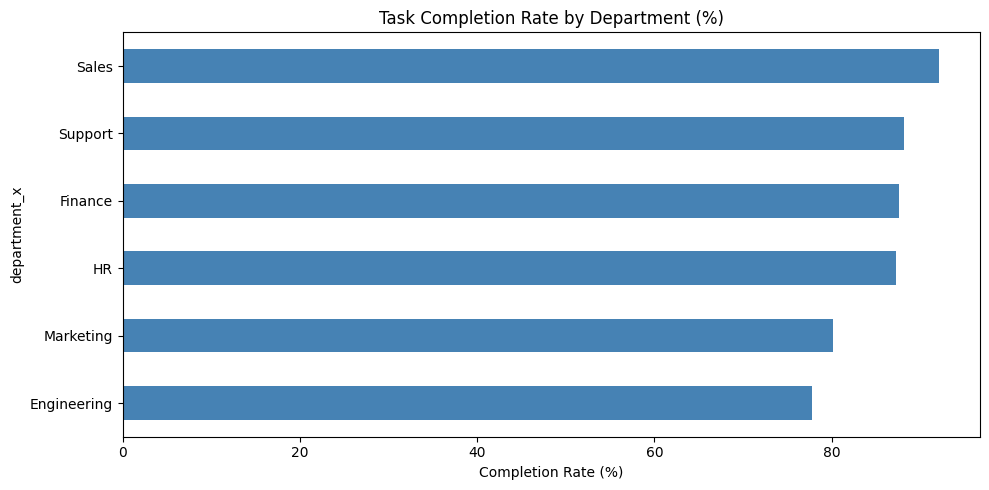

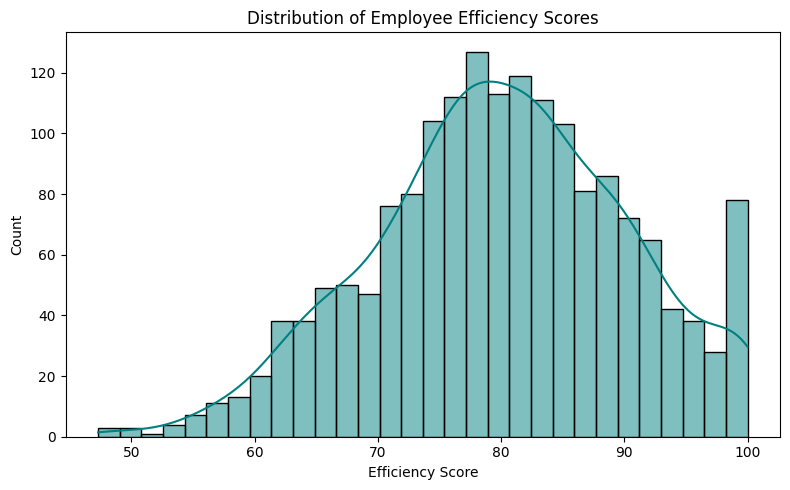

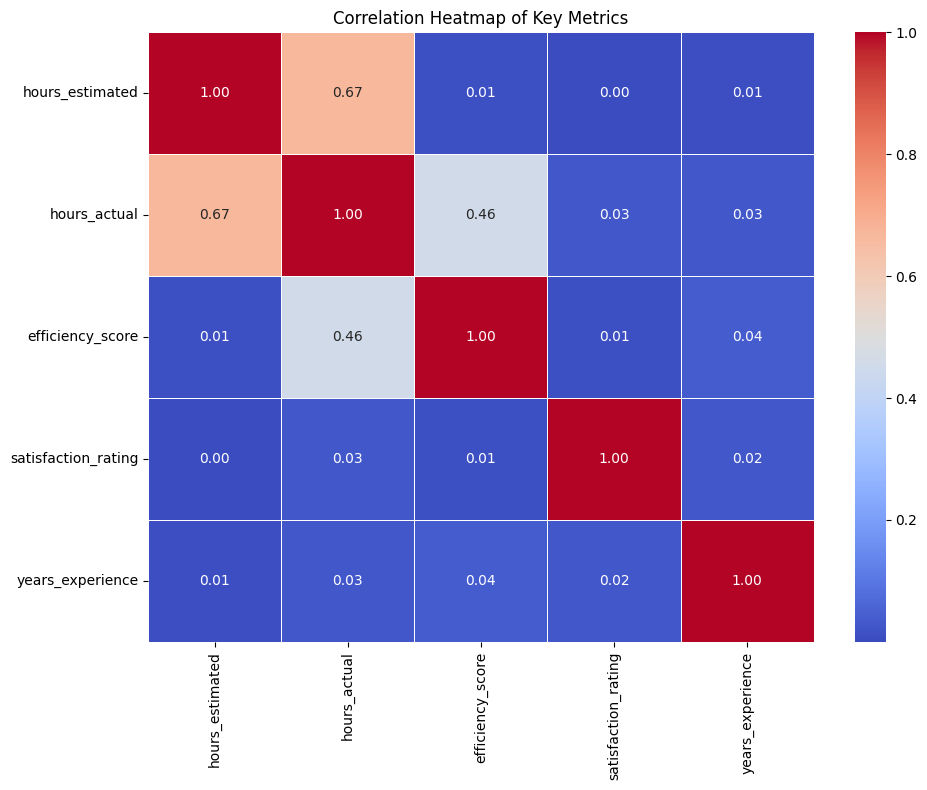

In [4]:
# Plot 1: Task completion by department
plt.figure(figsize=(10, 5))
dept_completion = merged.groupby('department_x')['completed'].mean() * 100
dept_completion.sort_values().plot(kind='barh', color='steelblue')
plt.title('Task Completion Rate by Department (%)')
plt.xlabel('Completion Rate (%)')
plt.tight_layout()
plt.savefig('../reports/dept_completion.png', dpi=150)
plt.show()

# Plot 2: Distribution of efficiency scores
plt.figure(figsize=(8, 5))
sns.histplot(merged[merged['efficiency_score'] > 0]['efficiency_score'], bins=30, kde=True, color='teal')
plt.title('Distribution of Employee Efficiency Scores')
plt.xlabel('Efficiency Score')
plt.tight_layout()
plt.savefig('../reports/efficiency_dist.png', dpi=150)
plt.show()

# Plot 3: Correlation heatmap
plt.figure(figsize=(10, 8))
numeric_cols = ['hours_estimated', 'hours_actual', 'efficiency_score', 
                'satisfaction_rating', 'years_experience']
corr = merged[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Key Metrics')
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png', dpi=150)
plt.show()

In [6]:
merged.to_csv('../data/processed/merged_data.csv', index=False)
print("Cleaned data saved!")

Cleaned data saved!
